# Đọc dữ liệu

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Load các bảng dữ liệu chính
drive_files = {
    'inventory': '1vAMltQY1HzyfYbSaqHmiX7vG3x-0nzgg',
    'products': '1ChaIE-mxZusnsUN3uPQLzrgO8iWFFB_o',
    'returns': '1MfqBi7Kvo2GEKG8PlERQPIB2NMqIsW5_',
    'payments': '1uauLXN2gHWTuN1Hznp9Bi98Z58PNyqZX',
    'web_traffic': '1YwWikoZJyQYEMrcc--CNweJF_wZ-9HF5',
    'orders': '1qgJAYEH1M5w5syZCHsCof4v5yYHDglZ8',
    'order_items': '189g8Scbtk_bwKeLgu1V93UMw9uMWYcC_',
    'geography': '1AoHEINjy0G6evkcn6G0ZQlSrRi-H8sCw',
    'shipments': '1Lhsc127N9EBu0rQTWrBMPjo9RJ0bxXQq',
    'reviews': '11uSO9FqGruJxtwiAtbOrn0bYqembKjky',
    'promotions': '1gOSK-MYviA_AqWcgC6P8H7wvfwHT-icy',
    'sales': '1wymVLHfIkObDNZDbG5OKauIpZF8_7srT',
    'customers': '1zOJVpKAvyZDhjrv8oN5X3q-8ESt7nK0C',
    'sample_submission': '1_csutoXN2ozsCnM07zFJHwG1bhwn9j5B'
}

dfs = {}

print("Đang tải dữ liệu, vui lòng đợi...")
for name, file_id in drive_files.items():
    url = f'https://drive.google.com/uc?export=download&id={file_id}'
    dfs[name] = pd.read_csv(url)
    print(f"Đã tải xong: {name}")

inventory = dfs['inventory']
orders = dfs['orders']
order_items = dfs['order_items']
payments = dfs['payments']
shipments = dfs['shipments']
returns = dfs['returns']
reviews = dfs['reviews']
geography = dfs['geography']
web_traffic = dfs['web_traffic']
products = dfs['products']
promotions = dfs['promotions']
sales = dfs['sales']
customers = dfs['customers']
sample_submission = dfs['sample_submission']

# Chuyển đổi định dạng ngày tháng
promotions['start_date'] = pd.to_datetime(promotions['start_date'])
promotions['end_date'] = pd.to_datetime(promotions['end_date'])
orders['order_date'] = pd.to_datetime(orders['order_date'])
shipments['ship_date'] = pd.to_datetime(shipments['ship_date'])
shipments['delivery_date'] = pd.to_datetime(shipments['delivery_date'])
inventory['snapshot_date'] = pd.to_datetime(inventory['snapshot_date'])
returns['return_date'] = pd.to_datetime(returns['return_date'])
reviews['review_date'] = pd.to_datetime(reviews['review_date'])
web_traffic['date'] = pd.to_datetime(web_traffic['date'])
sales['Date'] = pd.to_datetime(sales['Date'])

Đang tải dữ liệu, vui lòng đợi...
Đã tải xong: inventory
Đã tải xong: products
Đã tải xong: returns
Đã tải xong: payments
Đã tải xong: web_traffic
Đã tải xong: orders


/tmp/ipykernel_9307/1540230597.py:30: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  dfs[name] = pd.read_csv(url)


Đã tải xong: order_items
Đã tải xong: geography
Đã tải xong: shipments
Đã tải xong: reviews
Đã tải xong: promotions
Đã tải xong: sales
Đã tải xong: customers
Đã tải xong: sample_submission


# Xử lí dữ liệu

## customers & geography

In [55]:
# Merge để lấy thông tin Vùng (Region)
customers = customers.merge(geography[['zip', 'region']], on='zip', how='left')

# Chuyển đổi cột thời gian tạo tài khoản về cấp độ Ngày
customers['date'] = pd.to_datetime(customers['signup_date']).dt.floor('D')

# Sắp xếp tăng dần theo ngày
customers_sorted = customers.sort_values(by='date')

# Hàm gom nhóm theo ngày
def aggregate_customers_daily(df):
    # 1. Tạo bản gom nhóm cơ bản theo ngày
    daily_stats = df.groupby('date').agg(
        total_new_customers=('customer_id', 'count')
    )

    # 2. Thống kê theo Gender \
    gender_counts = df.pivot_table(
        index='date',
        columns='gender',
        values='customer_id',
        aggfunc='count',
        fill_value=0
    )
    gender_counts.columns = [f'gender_{col}' for col in gender_counts.columns]

    # 3. Thống kê theo Age Group
    age_counts = df.pivot_table(
        index='date',
        columns='age_group',
        values='customer_id',
        aggfunc='count',
        fill_value=0
    )
    age_counts.columns = [f'age_{col}' for col in age_counts.columns]

    # 4. Thống kê theo Acquisition Channel
    channel_counts = df.pivot_table(
        index='date',
        columns='acquisition_channel',
        values='customer_id',
        aggfunc='count',
        fill_value=0
    )
    channel_counts.columns = [f'channel_{col}' for col in channel_counts.columns]

    # 5. Thống kê theo Vùng (Region)
    region_counts = df.pivot_table(
        index='date',
        columns='region',
        values='customer_id',
        aggfunc='count',
        fill_value=0
    )
    region_counts.columns = [f'region_{col.lower()}' for col in region_counts.columns]

    # Kết hợp tất cả lại thành một DataFrame
    daily_df = pd.concat([daily_stats, gender_counts, age_counts, channel_counts,
                          region_counts], axis=1).fillna(0)

    daily_df = daily_df.cumsum()

    daily_df = daily_df.reset_index()

    return daily_df

customers_handled = aggregate_customers_daily(customers_sorted)

print(customers_handled.head())
print(f"Số dòng: {len(customers_handled)}")

        date  total_new_customers  gender_Female  gender_Male  \
0 2012-01-17                    1              0            1   
1 2012-01-20                    2              1            1   
2 2012-02-02                    3              1            2   
3 2012-02-05                    4              1            3   
4 2012-02-07                    5              2            3   

   gender_Non-binary  age_18-24  age_25-34  age_35-44  age_45-54  age_55+  \
0                  0          0          0          1          0        0   
1                  0          0          0          2          0        0   
2                  0          0          1          2          0        0   
3                  0          0          1          2          0        1   
4                  0          0          2          2          0        1   

   channel_direct  channel_email_campaign  channel_organic_search  \
0               1                       0                       0   
1       

## inventory

In [56]:
inventory['snapshot_date'] = pd.to_datetime(inventory['snapshot_date'])

def aggregate_inventory_monthly(df):
    # 1. Tổng hợp các chỉ số quan trọng theo từng tháng
    monthly_inv = df.groupby('snapshot_date').agg({
        'product_id': 'count',
        'stock_on_hand': 'sum',
        'units_received': 'sum',
        'units_sold': 'sum',
        'fill_rate': 'mean',
        'stockout_days': 'mean',
        'days_of_supply': 'mean',
        'stockout_flag': 'sum',
        'overstock_flag': 'sum',
        'reorder_flag': 'sum',
        'sell_through_rate': 'mean'
    })

    # 2. Thống kê theo category
    category_counts = df.pivot_table(
        index='snapshot_date',
        columns='category',
        values='product_id',
        aggfunc='count',
        fill_value=0
    )
    category_counts.columns = [f'category_{col.lower()}' for col in category_counts.columns]

    # 3. Thống kê theo segment
    segment_counts = df.pivot_table(
        index='snapshot_date',
        columns='segment',
        values='product_id',
        aggfunc='count',
        fill_value=0
    )
    segment_counts.columns = [f'segment_{col.lower()}' for col in segment_counts.columns]

    # Kết hợp tất cả lại thành một bảng snapshot hoàn chỉnh theo tháng
    full_monthly = pd.concat([monthly_inv, category_counts, segment_counts], axis=1)

    # 4. THỰC HIỆN DỊCH CHUYỂN (SHIFT)
    # Lùi toàn bộ dữ liệu xuống 1 hàng để tháng N-1 phục vụ cho tháng N
    # shift(1) sẽ đẩy dữ liệu hàng 1 xuống hàng 2, để lại NaN ở hàng đầu tiên
    inventory_features = full_monthly.shift(1)

    # Đổi tên các cột
    original_cols = inventory_features.columns
    inventory_features.columns = [f'prev_month_{col}' for col in original_cols]

    # 5. Tạo month_key
    # Cộng 1 ngày vào ngày cuối tháng (snapshot_date) để ra ngày đầu tháng sau
    inventory_features['month_year_key'] = (inventory_features.index + pd.Timedelta(days=1)).to_period('M')

    # Xóa dòng đầu tiên bị NaN do shift và reset index
    return inventory_features.dropna(subset=[inventory_features.columns[0]]).reset_index(drop=True)

inventory_sorted = inventory.sort_values(by='snapshot_date')
inventory_handled = aggregate_inventory_monthly(inventory_sorted)
print(inventory_handled.head())
print(f"Số dòng: {len(inventory_handled)}")

   prev_month_product_id  prev_month_stock_on_hand  prev_month_units_received  \
0                  395.0                   23698.0                     8796.0   
1                  423.0                   26249.0                    11799.0   
2                  424.0                   27519.0                     8552.0   
3                  437.0                   29194.0                     7732.0   
4                  411.0                   30134.0                     7276.0   

   prev_month_units_sold  prev_month_fill_rate  prev_month_stockout_days  \
0                 7451.0              0.966075                  1.017722   
1                 9983.0              0.944919                  1.652482   
2                 7303.0              0.950001                  1.500000   
3                 6622.0              0.952631                  1.421053   
4                 6251.0              0.959855                  1.204380   

   prev_month_days_of_supply  prev_month_stockout_flag  

## order_items & orders & products & shipments

In [57]:
orders = orders.merge(order_items, on='order_id', how='left')
orders = orders.merge(products, on='product_id', how='left')
orders = orders.merge(shipments, on='order_id', how='left')

print(orders.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 714669 entries, 0 to 714668
Data columns (total 24 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   order_id         714669 non-null  int64         
 1   order_date       714669 non-null  datetime64[ns]
 2   customer_id      714669 non-null  int64         
 3   zip              714669 non-null  int64         
 4   order_status     714669 non-null  object        
 5   payment_method   714669 non-null  object        
 6   device_type      714669 non-null  object        
 7   order_source     714669 non-null  object        
 8   product_id       714669 non-null  int64         
 9   quantity         714669 non-null  int64         
 10  unit_price       714669 non-null  float64       
 11  discount_amount  714669 non-null  float64       
 12  promo_id         276316 non-null  object        
 13  promo_id_2       206 non-null     object        
 14  product_name     714

In [58]:
orders['order_date'] = pd.to_datetime(orders['order_date'])
orders['final_price'] = orders['quantity'] * orders['unit_price']
orders['shipping_fee'] = orders['shipping_fee'].fillna(0)
orders['final_price'] = orders['final_price'] - orders['shipping_fee']
orders['cogs'] = orders['quantity'] * orders['cogs']
orders_sorted = orders.sort_values(by='order_date')

def aggregate_orders_daily(df):
    # 1. Tạo bản gom nhóm cơ bản theo ngày
    daily_stats = df.groupby('order_date').agg({
        'order_id': 'count',
        'customer_id': 'count'
    })

    allowed_status = ['created', 'delivered', 'paid', 'shipped', 'returned']
    filtered_df = df.loc[df['order_status'].isin(allowed_status)]

    # Tạo bản gom nhóm cơ bản theo ngày từ dữ liệu đã lọc
    daily_stats_1 = filtered_df.groupby('order_date').agg({
        'product_id': 'count',
        'quantity': 'sum',
        'final_price': 'sum',
        'discount_amount': 'sum',
        'cogs': 'sum',
        'promo_id': 'count',
        'promo_id_2': 'count',
    })

    # 2. Thống kê theo order_status
    order_status_counts = df.pivot_table(
        index='order_date',
        columns='order_status',
        values='order_id',
        aggfunc='count',
        fill_value=0
    )
    order_status_counts.columns = [f'order_status_{col.lower()}' for col in order_status_counts.columns]

    # 3. Thống kê theo payment_method
    payment_method_counts = df.pivot_table(
        index='order_date',
        columns='payment_method',
        values='order_id',
        aggfunc='count',
        fill_value=0
    )
    payment_method_counts.columns = [f'payment_method_{col.lower()}' for col in payment_method_counts.columns]

    # 4. Thống kê theo device_type
    device_type_counts = df.pivot_table(
        index='order_date',
        columns='device_type',
        values='order_id',
        aggfunc='count',
        fill_value=0
    )
    device_type_counts.columns = [f'device_type_{col.lower()}' for col in device_type_counts.columns]

    # 5. Thống kê theo order_source
    order_source_counts = df.pivot_table(
        index='order_date',
        columns='order_source',
        values='order_id',
        aggfunc='count',
        fill_value=0
    )
    order_source_counts.columns = [f'order_source_{col.lower()}' for col in order_source_counts.columns]

    # 6. Thống kê theo category
    category_counts = df.pivot_table(
        index='order_date',
        columns='category',
        values='product_id',
        aggfunc='count',
        fill_value=0
    )
    category_counts.columns = [f'category_{col.lower()}' for col in category_counts.columns]

    # 7. Thống kê theo segment
    segment_counts = df.pivot_table(
        index='order_date',
        columns='segment',
        values='product_id',
        aggfunc='count',
        fill_value=0
    )
    segment_counts.columns = [f'segment_{col.lower()}' for col in segment_counts.columns]

    # 8. Thống kê theo size
    size_counts = df.pivot_table(
        index='order_date',
        columns='size',
        values='product_id',
        aggfunc='count',
        fill_value=0
    )
    size_counts.columns = [f'size_{col.lower()}' for col in size_counts.columns]

    # 9. Thống kê theo color
    color_counts = df.pivot_table(
        index='order_date',
        columns='color',
        values='product_id',
        aggfunc='count',
        fill_value=0
    )
    color_counts.columns = [f'color_{col.lower()}' for col in color_counts.columns]

    # Kết hợp tất cả lại thành một DataFrame
    daily_df = pd.concat([daily_stats, daily_stats_1, order_status_counts, payment_method_counts,
                          device_type_counts, order_source_counts, category_counts,
                          segment_counts, size_counts, color_counts], axis=1).fillna(0)

    daily_df = daily_df.reset_index()

    return daily_df

orders_handled = aggregate_orders_daily(orders_sorted)

print(orders_handled.head())
print(f"Số dòng: {len(orders_handled)}")

  order_date  order_id  customer_id  product_id  quantity  final_price  \
0 2012-07-04       174          174         164       739   4968146.15   
1 2012-07-05       103          103          94       395   2520363.57   
2 2012-07-06        99           99          88       390   2646220.56   
3 2012-07-07        75           75          67       322   2337647.03   
4 2012-07-08        94           94          89       371   2198789.65   

   discount_amount          cogs  promo_id  promo_id_2  ...  color_black  \
0              0.0  3.856168e+06         0           0  ...           17   
1              0.0  1.962912e+06         0           0  ...           14   
2              0.0  2.171620e+06         0           0  ...           14   
3              0.0  1.864960e+06         0           0  ...            3   
4              0.0  1.671798e+06         0           0  ...            7   

   color_blue  color_green  color_orange  color_pink  color_purple  color_red  \
0          17    

## returns

In [59]:
returns['return_date'] = pd.to_datetime(returns['return_date'])
returns_sorted = returns.sort_values(by='return_date')

def aggregate_returns_daily(df):
    # 1. Tạo bản gom nhóm cơ bản theo ngày
    daily_stats = df.groupby('return_date').agg({
        'return_quantity': 'sum',
        'refund_amount': 'sum'
    })

    # 2. Thống kê theo return_reason
    return_reason_counts = df.pivot_table(
        index='return_date',
        columns='return_reason',
        values='order_id',
        aggfunc='count',
        fill_value=0
    )
    return_reason_counts.columns = [f'return_reason_{col.lower()}' for col in return_reason_counts.columns]

    # Kết hợp tất cả lại thành một DataFrame
    daily_df = pd.concat([daily_stats, return_reason_counts], axis=1).fillna(0)

    daily_df = daily_df.reset_index()

    return daily_df

returns_handled = aggregate_returns_daily(returns_sorted)

print(returns_handled.head())
print(f"Số dòng: {len(returns_handled)}")

  return_date  return_quantity  refund_amount  return_reason_changed_mind  \
0  2012-07-11                4        6493.75                           0   
1  2012-07-12                1        4834.00                           0   
2  2012-07-14                6       52967.00                           0   
3  2012-07-15                2       13534.62                           1   
4  2012-07-16                4       16170.54                           0   

   return_reason_defective  return_reason_late_delivery  \
0                        0                            0   
1                        0                            0   
2                        0                            1   
3                        0                            0   
4                        0                            0   

   return_reason_not_as_described  return_reason_wrong_size  
0                               0                         1  
1                               1                         

## web_traffic

In [60]:
web_traffic['date'] = pd.to_datetime(web_traffic['date'])
web_traffic_sorted = web_traffic.sort_values(by='date')
web_traffic[web_traffic['date'].duplicated()]

,date,sessions,unique_visitors,page_views,bounce_rate,avg_session_duration_sec,traffic_source


In [61]:
web_traffic_handled = pd.get_dummies(web_traffic, columns=['traffic_source'], dtype=int)
print(web_traffic_handled.head())
print(f"Số dòng: {len(web_traffic_handled)}")

        date  sessions  unique_visitors  page_views  bounce_rate  \
0 2013-01-01      9760             7253       39093      0.00514   
1 2013-01-02     10456             8151       47611      0.00406   
2 2013-01-03     10076             7458       36963      0.00401   
3 2013-01-04      9973             8063       53078      0.00562   
4 2013-01-05     10223             7882       36790      0.00525   

   avg_session_duration_sec  traffic_source_direct  \
0                     102.9                      0   
1                     120.5                      0   
2                     263.6                      1   
3                     151.8                      1   
4                     168.6                      0   

   traffic_source_email_campaign  traffic_source_organic_search  \
0                              0                              1   
1                              0                              1   
2                              0                              0  

## Tổng hợp

In [62]:
df_master = orders_handled.merge(
    returns_handled,
    left_on='order_date',
    right_on='return_date',
    how='left'
).fillna(0)
df_master.drop(columns=[
    'return_date', 'return_quantity', 'refund_amount',
    'final_price', 'cogs'
], inplace=True)

print(df_master.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3833 entries, 0 to 3832
Data columns (total 59 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   order_date                      3833 non-null   datetime64[ns]
 1   order_id                        3833 non-null   int64         
 2   customer_id                     3833 non-null   int64         
 3   product_id                      3833 non-null   int64         
 4   quantity                        3833 non-null   int64         
 5   discount_amount                 3833 non-null   float64       
 6   promo_id                        3833 non-null   int64         
 7   promo_id_2                      3833 non-null   int64         
 8   order_status_cancelled          3833 non-null   int64         
 9   order_status_created            3833 non-null   int64         
 10  order_status_delivered          3833 non-null   int64         
 11  orde

In [63]:
df_master = df_master.merge(
    web_traffic_handled,
    left_on='order_date',
    right_on='date',
    how='left'
).fillna(0)
df_master.drop(columns=['date'], inplace=True)
print(df_master.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3833 entries, 0 to 3832
Data columns (total 70 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   order_date                      3833 non-null   datetime64[ns]
 1   order_id                        3833 non-null   int64         
 2   customer_id                     3833 non-null   int64         
 3   product_id                      3833 non-null   int64         
 4   quantity                        3833 non-null   int64         
 5   discount_amount                 3833 non-null   float64       
 6   promo_id                        3833 non-null   int64         
 7   promo_id_2                      3833 non-null   int64         
 8   order_status_cancelled          3833 non-null   int64         
 9   order_status_created            3833 non-null   int64         
 10  order_status_delivered          3833 non-null   int64         
 11  orde

In [64]:
df_master = df_master.merge(
    customers_handled,
    left_on='order_date',
    right_on='date',
    how='left'
).fillna(0)
df_master.drop(columns=['date'], inplace=True)
print(df_master.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3833 entries, 0 to 3832
Data columns (total 88 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   order_date                      3833 non-null   datetime64[ns]
 1   order_id                        3833 non-null   int64         
 2   customer_id                     3833 non-null   int64         
 3   product_id                      3833 non-null   int64         
 4   quantity                        3833 non-null   int64         
 5   discount_amount                 3833 non-null   float64       
 6   promo_id                        3833 non-null   int64         
 7   promo_id_2                      3833 non-null   int64         
 8   order_status_cancelled          3833 non-null   int64         
 9   order_status_created            3833 non-null   int64         
 10  order_status_delivered          3833 non-null   int64         
 11  orde

In [65]:
df_master['month_year_key'] = df_master['order_date'].dt.to_period('M')

df_master = df_master.merge(
    inventory_handled,
    on='month_year_key',
    how='left'
).fillna(0)

df_master.drop(columns=['month_year_key'], inplace=True)
print(df_master.info())
print(df_master.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3833 entries, 0 to 3832
Columns: 111 entries, order_date to prev_month_segment_trendy
dtypes: datetime64[ns](1), float64(58), int64(52)
memory usage: 3.2 MB
None
  order_date  order_id  customer_id  product_id  quantity  discount_amount  \
0 2012-07-04       174          174         164       739              0.0   
1 2012-07-05       103          103          94       395              0.0   
2 2012-07-06        99           99          88       390              0.0   
3 2012-07-07        75           75          67       322              0.0   
4 2012-07-08        94           94          89       371              0.0   

   promo_id  promo_id_2  order_status_cancelled  order_status_created  ...  \
0         0           0                      10                     0  ...   
1         0           0                       9                     0  ...   
2         0           0                      11                     1  ...   
3      

In [66]:
df_master = df_master.merge(
    sales,
    left_on='order_date',
    right_on='Date',
    how='left'
).fillna(0)

df_master.drop(columns=['Date'], inplace=True)
df_master.rename(columns={'order_date': 'Date'}, inplace=True)
print(df_master.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3833 entries, 0 to 3832
Columns: 113 entries, Date to COGS
dtypes: datetime64[ns](1), float64(60), int64(52)
memory usage: 3.3 MB
None


# Kỹ thuật đặc trưng

In [67]:
# Danh sách các cột cần tạo đặc trưng trễ
columns_to_lag = [
    'Revenue', 'COGS', 'sessions', 'unique_visitors',
    'total_new_customers'
]

# Các khoảng trễ cần tạo
lag_periods = [1, 2, 7, 14, 30, 60, 90, 365]

# Tạo các đặc trưng trễ
for col in columns_to_lag:
    for lag in lag_periods:
        new_col_name = f'{col}_lag_{lag}'
        df_master[new_col_name] = df_master[col].shift(lag).fillna(0)

print(df_master.head())
print(f"Số cột sau khi thêm đặc trưng trễ: {df_master.shape[1]}")

        Date  order_id  customer_id  product_id  quantity  discount_amount  \
0 2012-07-04       174          174         164       739              0.0   
1 2012-07-05       103          103          94       395              0.0   
2 2012-07-06        99           99          88       390              0.0   
3 2012-07-07        75           75          67       322              0.0   
4 2012-07-08        94           94          89       371              0.0   

   promo_id  promo_id_2  order_status_cancelled  order_status_created  ...  \
0         0           0                      10                     0  ...   
1         0           0                       9                     0  ...   
2         0           0                      11                     1  ...   
3         0           0                       8                     3  ...   
4         0           0                       5                     3  ...   

   unique_visitors_lag_90  unique_visitors_lag_365  total_new_

In [68]:
df_master_sorted = df_master.sort_values(by='Date').copy()

columns_to_roll = [
    'Revenue', 'COGS', 'sessions', 'unique_visitors',
    'total_new_customers', 'order_id', 'quantity', 'discount_amount',
    'page_views', 'bounce_rate', 'avg_session_duration_sec',
    'order_status_returned', 'order_status_cancelled',
    'payment_method_credit_card', 'device_type_mobile', 'order_source_organic_search'
]

# Các kích thước cửa sổ trượt
window_sizes = [3, 7, 14, 30, 60, 90]

# Các phương pháp tổng hợp cho cửa sổ trượt
agg_methods = ['mean', 'sum', 'std']

for col in columns_to_roll:
    for window in window_sizes:
        for method in agg_methods:
            new_col_name = f'{col}_roll_{method}_{window}d'
            if method == 'mean':
                df_master_sorted[new_col_name] = df_master_sorted[col].shift(1).rolling(window=window, closed='left').mean().fillna(0)
            elif method == 'sum':
                df_master_sorted[new_col_name] = df_master_sorted[col].shift(1).rolling(window=window, closed='left').sum().fillna(0)
            elif method == 'std':
                df_master_sorted[new_col_name] = df_master_sorted[col].shift(1).rolling(window=window, closed='left').std().fillna(0)

df_master = df_master_sorted.copy()

print(f"Số cột sau khi thêm đặc trưng cửa sổ trượt: {df_master.shape[1]}")
print(df_master.head())

Số cột sau khi thêm đặc trưng cửa sổ trượt: 441
        Date  order_id  customer_id  product_id  quantity  discount_amount  \
0 2012-07-04       174          174         164       739              0.0   
1 2012-07-05       103          103          94       395              0.0   
2 2012-07-06        99           99          88       390              0.0   
3 2012-07-07        75           75          67       322              0.0   
4 2012-07-08        94           94          89       371              0.0   

   promo_id  promo_id_2  order_status_cancelled  order_status_created  ...  \
0         0           0                      10                     0  ...   
1         0           0                       9                     0  ...   
2         0           0                      11                     1  ...   
3         0           0                       8                     3  ...   
4         0           0                       5                     3  ...   

   order_sourc

/tmp/ipykernel_9307/2340038898.py:24: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_master_sorted[new_col_name] = df_master_sorted[col].shift(1).rolling(window=window, closed='left').sum().fillna(0)
/tmp/ipykernel_9307/2340038898.py:26: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_master_sorted[new_col_name] = df_master_sorted[col].shift(1).rolling(window=window, closed='left').std().fillna(0)
/tmp/ipykernel_9307/2340038898.py:22: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `

# Phân chia dữ liệu (Train-Test Split) theo thời gian

In [69]:
!pip install holidays pandas_market_calendars

In [70]:
!pip install prophet

In [71]:
import pandas as pd
import numpy as np
import holidays

# 1. ĐỊNH NGHĨA SỰ KIỆN VÀ NGÀY LỄ (HOLIDAYS & PROMOS)

# 1.1 Ngày lễ công cộng tại Việt Nam
vn_holidays = holidays.VN(years=range(2012, 2026))

# 1.2 Các mốc Tết Âm lịch
tet_dates = {
    2013: '2013-02-10', 2014: '2014-01-31', 2015: '2015-02-19', 2016: '2016-02-08',
    2017: '2017-01-28', 2018: '2018-02-16', 2019: '2019-02-05', 2020: '2020-01-25',
    2021: '2021-02-12', 2022: '2022-02-01', 2023: '2023-01-22', 2024: '2024-02-10',
    2025: '2025-01-29'
}
tet_dates_dt = {year: pd.to_datetime(date_str) for year, date_str in tet_dates.items()}

# 1.3 Lịch Mega Sales (11/11, 12/12)
fixed_mega_sale_dates = []
for year in range(2013, 2026):
    fixed_mega_sale_dates.extend([f'{year}-11-11', f'{year}-12-12'])
fixed_mega_sale_dates = pd.to_datetime(fixed_mega_sale_dates)

# 1.4 Lịch Black Friday & Cyber Monday
def get_bf_cm_dates(years):
    dates = []
    for year in years:
        last_day_nov = pd.Timestamp(year, 11, 30)
        # Tìm ngày thứ 6 cuối cùng của tháng 11
        black_friday = last_day_nov - pd.Timedelta(days=(last_day_nov.dayofweek - 4) % 7)
        cyber_monday = black_friday + pd.Timedelta(days=3)
        dates.extend([black_friday, cyber_monday])
    return pd.to_datetime(dates)

bf_cm_dates = get_bf_cm_dates(range(2013, 2026))
mega_sale_dates = pd.to_datetime(list(set(fixed_mega_sale_dates.tolist() + bf_cm_dates.tolist())))

# 1.5 Lịch Weekend Promo (Tùy chỉnh theo chiến dịch)
weekend_promo_dates = pd.to_datetime([
    '2013-03-02', '2013-03-03', '2014-07-19', '2014-07-20',
    '2015-09-05', '2015-09-06', '2016-04-23', '2016-04-24',
    '2017-06-17', '2017-06-18', '2018-08-11', '2018-08-12',
    '2019-10-26', '2019-10-27', '2020-12-05', '2020-12-06',
    '2021-02-20', '2021-02-21', '2022-05-14', '2022-05-15',
    '2023-01-28', '2023-01-29', '2024-03-09', '2024-03-10'
])

print("Đã nạp thành công lịch Sự kiện và Ngày lễ.")

# 2. HÀM TẠO ĐẶC TRƯNG CHÍNH (FEATURE ENGINEERING)

def calculate_days_to_tet(date):
    for year in sorted(tet_dates_dt.keys()):
        if tet_dates_dt[year] >= date:
            return (tet_dates_dt[year] - date).days
    return 365 # Mặc định nếu không tìm thấy Tết tương lai

def create_features(df, min_date_for_ordinal):
    df = df.copy()
    df['dayofweek'] = df['Date'].dt.dayofweek
    df['quarter'] = df['Date'].dt.quarter
    df['month'] = df['Date'].dt.month
    df['year'] = df['Date'].dt.year
    df['dayofyear'] = df['Date'].dt.dayofyear
    df['is_weekend'] = df['dayofweek'].apply(lambda x: 1 if x >= 5 else 0)
    df['ordinal_date'] = (df['Date'] - min_date_for_ordinal).dt.days
    df['month_sin'] = np.sin(2 * np.pi * df['month']/12)
    df['month_cos'] = np.cos(2 * np.pi * df['month']/12)
    df['weekofyear'] = df['Date'].dt.isocalendar().week.astype(int)
    df['dayofmonth'] = df['Date'].dt.day
    df['weekofyear_sin'] = np.sin(2 * np.pi * df['weekofyear']/52)
    df['weekofyear_cos'] = np.cos(2 * np.pi * df['weekofyear']/52)
    df['dayofmonth_sin'] = np.sin(2 * np.pi * df['dayofmonth']/31)
    df['dayofmonth_cos'] = np.cos(2 * np.pi * df['dayofmonth']/31)
    df['is_holiday'] = df['Date'].apply(lambda x: 1 if x in vn_holidays else 0)
    df['is_mega_sale'] = df['Date'].isin(mega_sale_dates).astype(int)
    df['is_weekend_promo'] = df['Date'].isin(weekend_promo_dates).astype(int)
    df['is_payday'] = df['Date'].dt.day.isin([1, 5]).astype(int)
    df['days_to_Tet'] = df['Date'].apply(calculate_days_to_tet)
    xmas_this_year = pd.to_datetime(df['year'].astype(str) + '-12-25')
    xmas_next_year = pd.to_datetime((df['year'] + 1).astype(str) + '-12-25')
    df['days_to_christmas'] = (xmas_this_year - df['Date']).dt.days
    df.loc[df['days_to_christmas'] < 0, 'days_to_christmas'] = (xmas_next_year[df['days_to_christmas'] < 0] - df.loc[df['days_to_christmas'] < 0, 'Date']).dt.days
    ny_this_year = pd.to_datetime(df['year'].astype(str) + '-01-01')
    ny_next_year = pd.to_datetime((df['year'] + 1).astype(str) + '-01-01')
    df['days_to_new_year'] = (ny_this_year - df['Date']).dt.days
    df.loc[df['days_to_new_year'] < 0, 'days_to_new_year'] = (ny_next_year[df['days_to_new_year'] < 0] - df.loc[df['days_to_new_year'] < 0, 'Date']).dt.days
    df['days_in_month'] = df['Date'].dt.days_in_month
    df['days_to_month_end'] = df['days_in_month'] - df['Date'].dt.day
    df['is_month_end_sale'] = df['days_to_month_end'].apply(lambda x: 1 if x <= 3 else 0)
    df['is_peak_payday'] = df['days_to_month_end'].apply(lambda x: 1 if x == 1 else 0)
    return df

# 3. CHIA TẬP DỮ LIỆU & ÁP DỤNG HÀM TẠO ĐẶC TRƯNG

split_point = int(len(df_master) * 0.8)
df_train = df_master.iloc[:split_point].copy()
df_test = df_master.iloc[split_point:].copy()

global_min_date = df_master['Date'].min()

# Áp dụng tính năng (Features)
df_train_features = create_features(df_train, global_min_date)
df_test_features = create_features(df_test, global_min_date)

# 4. CHỌN LỌC ĐẶC TRƯNG CUỐI CÙNG (FEATURE SELECTION)

# 4.1 Lấy danh sách cột động
lag_and_roll_cols = [col for col in df_master.columns if '_lag_' in col or '_roll_mean_' in col]
prev_month_cols = [col for col in df_master.columns if col.startswith('prev_month_')]

# 4.2 Tổng hợp các cột cần giữ lại
features_to_keep = [
    'dayofweek', 'quarter', 'month', 'year', 'dayofyear', 'is_weekend',
    'ordinal_date', 'month_sin', 'month_cos',
    'weekofyear', 'dayofmonth', 'weekofyear_sin', 'weekofyear_cos', 'dayofmonth_sin', 'dayofmonth_cos',
    'is_holiday', 'is_mega_sale', 'is_weekend_promo', 'is_payday',
    'days_to_Tet', 'days_to_christmas', 'days_to_new_year',
    'days_to_month_end', 'is_month_end_sale', 'is_peak_payday'
] + lag_and_roll_cols + prev_month_cols

# 4.3 Khớp với dữ liệu thực tế (Đề phòng cột bị thiếu)
actual_features_train = [col for col in features_to_keep if col in df_train_features.columns]
actual_features_test = [col for col in features_to_keep if col in df_test_features.columns]

# 4.4 Tách X và y
X_train = df_train_features[actual_features_train]
X_test = df_test_features[actual_features_test]

y_train = df_train_features['Revenue'] # Chỉ dự đoán Revenue
y_test = df_test_features['Revenue']   # Chỉ dự đoán Revenue

print(f"\nKích thước X_train sau khi xử lý: {X_train.shape}")
print(f"Kích thước X_test sau khi xử lý: {X_test.shape}")
print("Đã hoàn tất nạp đặc trưng và phân tách dữ liệu.")

Đã nạp thành công lịch Sự kiện và Ngày lễ.

Kích thước X_train sau khi xử lý: (3066, 184)
Kích thước X_test sau khi xử lý: (767, 184)
Đã hoàn tất nạp đặc trưng và phân tách dữ liệu.


# Kỹ thuật đặc trưng: Đặc trưng tương tác (Interaction Features)


In [72]:
# Danh sách các đặc trưng gốc để tạo tương tác
# Chọn các cờ sự kiện và các biến liên quan đến web traffic/khách hàng
base_features_for_interaction = [
    ('is_holiday', 'sessions'),
    ('is_holiday', 'page_views'),
    ('is_mega_sale', 'sessions'),
    ('is_mega_sale', 'page_views'),
    ('is_weekend_promo', 'sessions'),
    ('is_weekend_promo', 'page_views'),
    ('is_payday', 'sessions'),
    ('is_payday', 'page_views'),
    ('days_to_Tet', 'sessions'),
    ('days_to_christmas', 'sessions'),
    ('days_to_month_end', 'sessions'),
    ('total_new_customers', 'sessions'),
    ('total_new_customers', 'page_views')
]

new_interaction_features = []

for df_set in [df_train_features, df_test_features]:
    for f1, f2 in base_features_for_interaction:
        new_col_name = f'{f1}_{f2}'
        if f1 in df_set.columns and f2 in df_set.columns:
            df_set[new_col_name] = df_set[f1] * df_set[f2]
            if new_col_name not in new_interaction_features:
                new_interaction_features.append(new_col_name)
        else:
            print(f"Warning: Feature {f1} or {f2} not found for interaction {new_col_name}")

# Cập nhật danh sách các đặc trưng cần giữ lại
# Sử dụng set để loại bỏ trùng lặp nếu có, sau đó chuyển lại thành list
features_to_keep = list(set(features_to_keep + new_interaction_features))

# Khớp với dữ liệu thực tế
actual_features_train = [col for col in features_to_keep if col in df_train_features.columns]
actual_features_test = [col for col in features_to_keep if col in df_test_features.columns]

# Tách lại X và y với các đặc trưng tương tác mới
X_train = df_train_features[actual_features_train]
X_test = df_test_features[actual_features_test]

y_train = df_train_features['Revenue']
y_test = df_test_features['Revenue']

X_train_xgb = X_train.drop(columns=['ordinal_date', 'year'], errors='ignore')
X_test_xgb = X_test.drop(columns=['ordinal_date', 'year'], errors='ignore')

print("Đã hoàn tất tạo đặc trưng tương tác và cập nhật X_train, X_test.")

Đã hoàn tất tạo đặc trưng tương tác và cập nhật X_train, X_test.


In [73]:
print(f"Kích thước X_train sau khi thêm đặc trưng tương tác: {X_train.shape}")
print(f"Kích thước X_test sau khi thêm đặc trưng tương tác: {X_test.shape}")
print(f"Kích thước X_train_xgb sau khi thêm đặc trưng tương tác: {X_train_xgb.shape}")
print(f"Kích thước X_test_xgb sau khi thêm đặc trưng tương tác: {X_test_xgb.shape}")

Kích thước X_train sau khi thêm đặc trưng tương tác: (3066, 197)
Kích thước X_test sau khi thêm đặc trưng tương tác: (767, 197)
Kích thước X_train_xgb sau khi thêm đặc trưng tương tác: (3066, 195)
Kích thước X_test_xgb sau khi thêm đặc trưng tương tác: (767, 195)


# Huấn luyện mô hình

In [74]:
import pandas as pd
from prophet import Prophet
import numpy as np # Keep numpy for evaluation later if needed

print("Bắt đầu huấn luyện mô hình Facebook Prophet...")

df_prophet_train = df_train_features[['Date', 'Revenue']].rename(columns={'Date': 'ds', 'Revenue': 'y'})
df_prophet_test = df_test_features[['Date', 'Revenue']].rename(columns={'Date': 'ds', 'Revenue': 'y'})

# SỬ DỤNG WINDOWS ĐỂ BẮT HIỆU ỨNG CHỜ SALE (ĐÁY)
holidays_list = []

for date, name in sorted(vn_holidays.items()):
    holidays_list.append({'holiday': name, 'ds': date, 'lower_window': -1, 'upper_window': 1})

for date in mega_sale_dates:
    holidays_list.append({'holiday': 'Mega Sale', 'ds': date, 'lower_window': -2, 'upper_window': 2})

for date in weekend_promo_dates:
    holidays_list.append({'holiday': 'Weekend Promo', 'ds': date, 'lower_window': -1, 'upper_window': 1})

# CHUYỂN SỰ KIỆN TỪ REGRESSORS SANG HOLIDAYS
all_features = pd.concat([df_train_features, df_test_features])

paydays = all_features[all_features['is_payday'] == 1]['Date'].unique()
for date in paydays:
    holidays_list.append({'holiday': 'Payday', 'ds': date, 'lower_window': -1, 'upper_window': 2})

month_ends = all_features[all_features['is_month_end_sale'] == 1]['Date'].unique()
for date in month_ends:
    holidays_list.append({'holiday': 'Month End Sale', 'ds': date, 'lower_window': -2, 'upper_window': 1})

holidays_df = pd.DataFrame(holidays_list)
holidays_df['ds'] = pd.to_datetime(holidays_df['ds'])
holidays_df = holidays_df[(holidays_df['ds'] >= df_prophet_train['ds'].min()) & (holidays_df['ds'] <= df_prophet_test['ds'].max())]

prophet_regressors = [
    'dayofweek', 'quarter', 'month', 'year', 'dayofyear', 'is_weekend',
    'ordinal_date', 'month_sin', 'month_cos', 'weekofyear', 'dayofmonth',
    'weekofyear_sin', 'weekofyear_cos', 'dayofmonth_sin', 'dayofmonth_cos',
    'days_to_Tet', 'days_to_christmas', 'days_to_new_year',
    'days_in_month', 'days_to_month_end'
]

for regressor in prophet_regressors:
    if regressor in df_train_features.columns:
        df_prophet_train[regressor] = df_train_features[regressor]
    if regressor in df_test_features.columns:
        df_prophet_test[regressor] = df_test_features[regressor]

model_prophet = Prophet(
    growth='linear',
    seasonality_mode='multiplicative',
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    holidays=holidays_df,
    changepoint_prior_scale=0.05,
    holidays_prior_scale=10.0
)

for regressor in prophet_regressors:
    model_prophet.add_regressor(regressor)

model_prophet.fit(df_prophet_train, seed=42)

print("Hoàn tất huấn luyện mô hình Facebook Prophet.")

future = model_prophet.make_future_dataframe(periods=len(df_prophet_test), include_history=False)
future['ds'] = df_prophet_test['ds'].reset_index(drop=True)

for regressor in prophet_regressors:
    if regressor in df_prophet_test.columns:
        future[regressor] = df_prophet_test[regressor].reset_index(drop=True)


forecast = model_prophet.predict(future)

y_pred_rev_prophet = forecast['yhat'].values

print("Đã tạo dự báo từ Facebook Prophet cho Revenue.")

Bắt đầu huấn luyện mô hình Facebook Prophet...
Hoàn tất huấn luyện mô hình Facebook Prophet.
Đã tạo dự báo từ Facebook Prophet cho Revenue.


# Đánh giá hiệu suất và tinh chỉnh mô hình


--- BÁO CÁO ĐÁNH GIÁ: Facebook Prophet Model ---
[Revenue]
  - RMSE: 1,123,570.24
  - MAE (Lệch trung bình): 804,532.88
  - MAPE (Lệch %): 28.60%
  - R2 Score: 0.5469


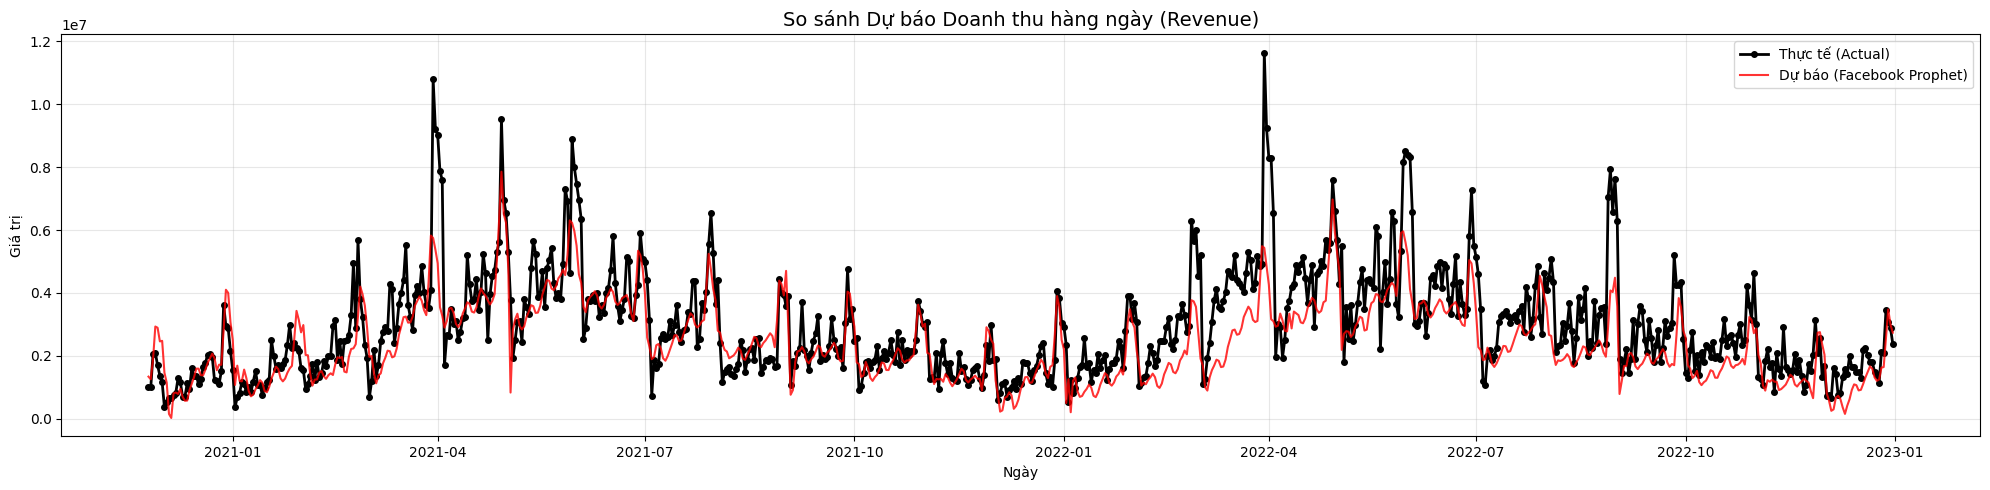

In [75]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Hàm hỗ trợ tính MAPE (Sai số phần trăm tuyệt đối trung bình)
def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100 if np.mean(y_true) != 0 else np.nan

def evaluate_model(y_true, y_pred, model_name, target_name):
    print(f"\n--- BÁO CÁO ĐÁNH GIÁ: {model_name} ---")

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    err_pct = mape(y_true, y_pred)

    print(f"[{target_name}]")
    print(f"  - RMSE: {rmse:,.2f}")
    print(f"  - MAE (Lệch trung bình): {mae:,.2f}")
    print(f"  - MAPE (Lệch %): {err_pct:.2f}%")
    print(f"  - R2 Score: {r2:.4f}")

y_test_actual = df_prophet_test['y']
y_pred_rev_prophet_actual = y_pred_rev_prophet

# Đánh giá chi tiết và trực quan hóa kết quả dự đoán
evaluate_model(y_test_actual, y_pred_rev_prophet_actual, "Facebook Prophet Model", "Revenue")

# Trực quan hóa kết quả dự đoán
plot_dates = df_prophet_test['ds']

plt.figure(figsize=(20, 5))

# Biểu đồ cho Revenue
plt.plot(plot_dates, y_test_actual, label='Thực tế (Actual)', color='black', linewidth=2, marker='o', markersize=4)
plt.plot(plot_dates, y_pred_rev_prophet_actual, label='Dự báo (Facebook Prophet)', linestyle='-', alpha=0.8, color='red')
plt.title('So sánh Dự báo Doanh thu hàng ngày (Revenue)', fontsize=14)
plt.ylabel('Giá trị')
plt.xlabel('Ngày')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Dự đoán Doanh thu & COGS cho tương lai (2023-2024) và Xuất CSV

In [76]:
import pandas as pd
import numpy as np
from prophet import Prophet

# 1. TẠO ĐẶC TRƯNG CHO CẢ LỊCH SỬ VÀ TƯƠNG LAI
# Dữ liệu lịch sử
df_master_with_features = create_features(df_master.copy(), global_min_date)

# Dữ liệu tương lai (1.5 năm)
future_dates = pd.date_range(start='2023-01-01', end='2024-07-01', freq='D')
future_df_for_regressors = pd.DataFrame({'Date': future_dates})
future_df_for_regressors = create_features(future_df_for_regressors, global_min_date)

# Gộp chung để lấy danh sách CÁC NGÀY SỰ KIỆN ĐỘNG xuyên suốt mốc thời gian
all_features = pd.concat([df_master_with_features, future_df_for_regressors])

# 2. XÂY DỰNG TẬP HOLIDAYS VỚI CỬA SỔ (WINDOWS) TỐI ƯU ĐÁY
holidays_list = []

for date, name in sorted(vn_holidays.items()):
    holidays_list.append({'holiday': name, 'ds': date, 'lower_window': -1, 'upper_window': 1})

for date in mega_sale_dates:
    holidays_list.append({'holiday': 'Mega Sale', 'ds': date, 'lower_window': -2, 'upper_window': 2})

for date in weekend_promo_dates:
    holidays_list.append({'holiday': 'Weekend Promo', 'ds': date, 'lower_window': -1, 'upper_window': 1})

paydays = all_features[all_features['is_payday'] == 1]['Date'].unique()
for date in paydays:
    holidays_list.append({'holiday': 'Payday', 'ds': date, 'lower_window': -1, 'upper_window': 2})

month_ends = all_features[all_features['is_month_end_sale'] == 1]['Date'].unique()
for date in month_ends:
    holidays_list.append({'holiday': 'Month End Sale', 'ds': date, 'lower_window': -2, 'upper_window': 1})

holidays_df_full = pd.DataFrame(holidays_list)
holidays_df_full['ds'] = pd.to_datetime(holidays_df_full['ds'])

min_date = df_master_with_features['Date'].min()
max_date = future_dates.max()
holidays_df_full = holidays_df_full[(holidays_df_full['ds'] >= min_date) & (holidays_df_full['ds'] <= max_date)]

# 3. CHUẨN BỊ TẬP REGRESSORS VÀ DATA CHO PROPHET
prophet_regressors = [
    'dayofweek', 'quarter', 'month', 'year', 'dayofyear', 'is_weekend',
    'ordinal_date', 'month_sin', 'month_cos', 'weekofyear', 'dayofmonth',
    'weekofyear_sin', 'weekofyear_cos', 'dayofmonth_sin', 'dayofmonth_cos',
    'days_to_Tet', 'days_to_christmas', 'days_to_new_year',
    'days_in_month', 'days_to_month_end'
]

df_prophet_full = df_master_with_features[['Date', 'Revenue']].rename(columns={'Date': 'ds', 'Revenue': 'y'})
for regressor in prophet_regressors:
    df_prophet_full[regressor] = df_master_with_features[regressor]

# 4. HUẤN LUYỆN MÔ HÌNH PROPHET
print("Bắt đầu huấn luyện mô hình Facebook Prophet trên toàn bộ dữ liệu lịch sử...")
model_prophet_full = Prophet(
    growth='linear',
    seasonality_mode='multiplicative',
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    holidays=holidays_df_full,
    changepoint_prior_scale=0.05,
    holidays_prior_scale=10.0
)

for regressor in prophet_regressors:
    model_prophet_full.add_regressor(regressor)

model_prophet_full.fit(df_prophet_full, seed=42)
print("Hoàn tất huấn luyện mô hình Facebook Prophet.")

# 5. DỰ BÁO TƯƠNG LAI
print("Bắt đầu dự báo cho các ngày tương lai...")

future_dates_df = pd.DataFrame({'ds': future_dates})
for regressor in prophet_regressors:
    future_dates_df[regressor] = future_df_for_regressors[regressor]

forecast_future = model_prophet_full.predict(future_dates_df)

# Xử lý kết quả dự báo
final_pred_rev_future = forecast_future['yhat'].values
final_pred_rev_future = np.maximum(final_pred_rev_future, 0)

# Lấy COGS từ file sample_submission
df_sample = pd.read_csv('https://drive.google.com/uc?export=download&id=1_csutoXN2ozsCnM07zFJHwG1bhwn9j5B')
df_sample['Date'] = pd.to_datetime(df_sample['Date'])
df_sample_indexed = df_sample.set_index('Date')

predictions_list = []
for i, current_date in enumerate(future_dates):
    final_pred_cogs = df_sample_indexed.loc[current_date, 'COGS'] if current_date in df_sample_indexed.index else 0
    predictions_list.append({
        'Date': current_date,
        'Revenue': final_pred_rev_future[i],
        'COGS': final_pred_cogs
    })

# XUẤT KẾT QUẢ
df_future_pred = pd.DataFrame(predictions_list)
print("\nFuture Predictions (Top 5):")
print(df_future_pred.head())

output_filename = 'submission.csv'
df_future_pred.to_csv(output_filename, index=False)
print(f"Hoàn thành! Kết quả dự báo đã được lưu vào '{output_filename}'")

Bắt đầu huấn luyện mô hình Facebook Prophet trên toàn bộ dữ liệu lịch sử...
Hoàn tất huấn luyện mô hình Facebook Prophet.
Bắt đầu dự báo cho các ngày tương lai...

Future Predictions (Top 5):
        Date       Revenue        COGS
0 2023-01-01  2.593281e+06  2518885.15
1 2023-01-02  7.564335e+05  1136463.00
2 2023-01-03  1.341787e+06   822721.12
3 2023-01-04  1.704780e+06   914554.18
4 2023-01-05  1.416415e+06   984390.24
Hoàn thành! Kết quả dự báo đã được lưu vào 'submission.csv'


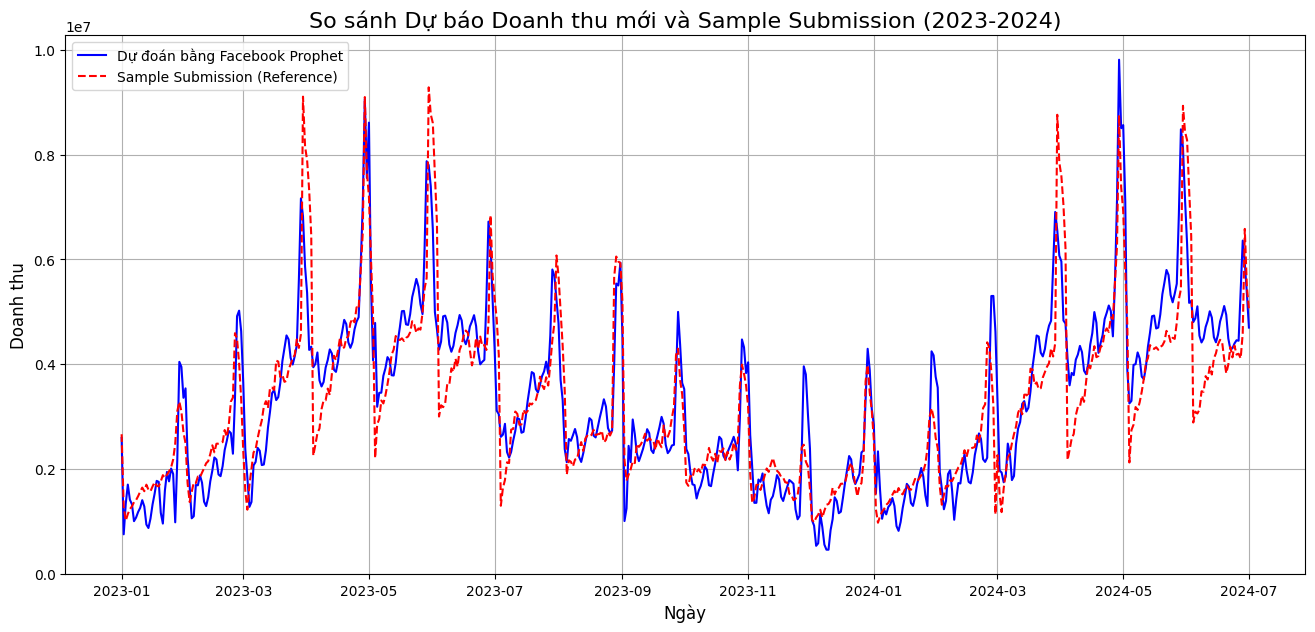

In [77]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

output_filename = 'submission.csv'
df_future_pred = pd.read_csv(output_filename)
df_future_pred['Date'] = pd.to_datetime(df_future_pred['Date'])

df_sample = pd.read_csv('https://drive.google.com/uc?export=download&id=1_csutoXN2ozsCnM07zFJHwG1bhwn9j5B')
df_sample['Date'] = pd.to_datetime(df_sample['Date'])

plt.figure(figsize=(16, 7))
sns.lineplot(x='Date', y='Revenue', data=df_future_pred, label='Dự đoán bằng Facebook Prophet', color='blue') # Updated label
sns.lineplot(x='Date', y='Revenue', data=df_sample, label='Sample Submission (Reference)', color='red', linestyle='--')
plt.title('So sánh Dự báo Doanh thu mới và Sample Submission (2023-2024)', fontsize=16)
plt.xlabel('Ngày', fontsize=12)
plt.ylabel('Doanh thu', fontsize=12)
plt.legend()
plt.grid(True)
plt.show()

# Giải thích yếu tố dẫn động doanh thu bằng SHAP Values


Bắt đầu tính toán SHAP values...


  0%|          | 0/50 [00:00<?, ?it/s]

Đã hoàn tất tính toán SHAP values.
Tạo biểu đồ tóm tắt SHAP...


/tmp/ipykernel_9307/2604792393.py:56: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, shap.sample(X_test_regressors, 50, random_state=42), plot_type="bar", show=False)


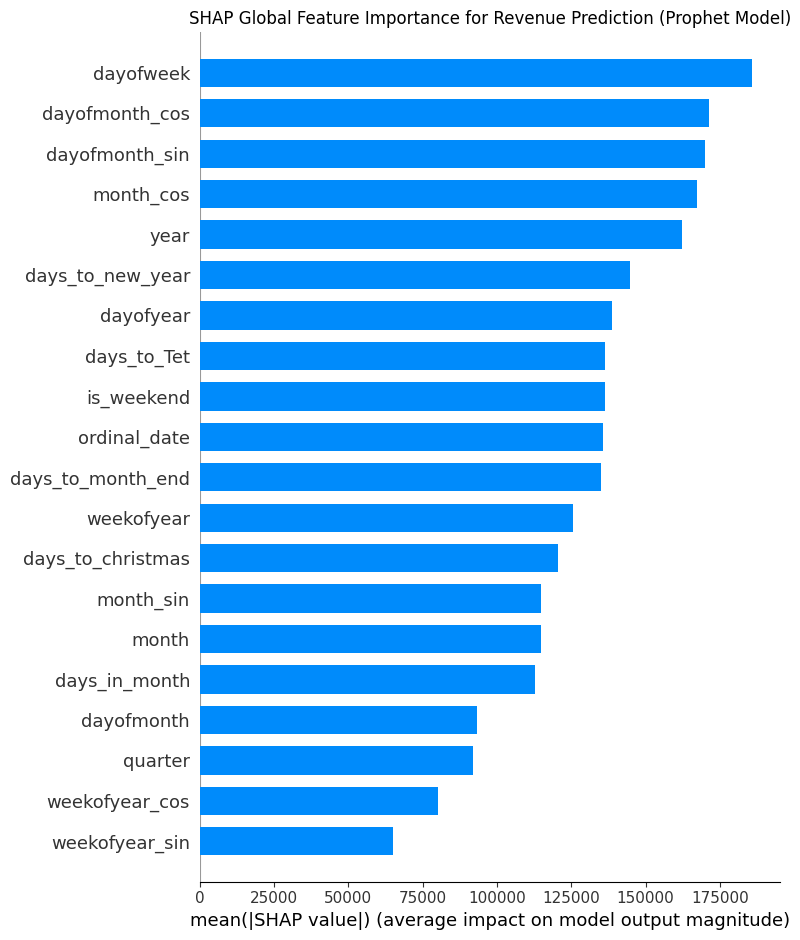

Tạo biểu đồ tác động SHAP...


/tmp/ipykernel_9307/2604792393.py:63: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, shap.sample(X_test_regressors, 50, random_state=42), show=False)


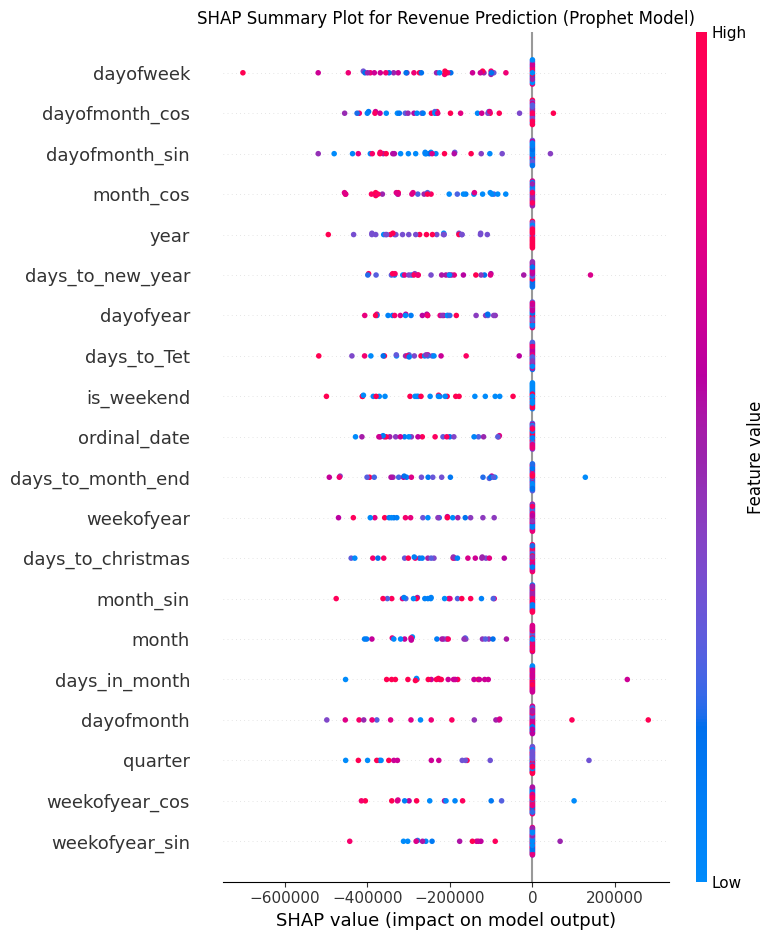

In [78]:
import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
print("Bắt đầu tính toán SHAP values...")

# 1. Chuẩn bị dữ liệu cho SHAP
# Danh sách các regressors đã sử dụng trong mô hình Prophet
prophet_regressors = [
    'dayofweek', 'quarter', 'month', 'year', 'dayofyear', 'is_weekend',
    'ordinal_date', 'month_sin', 'month_cos', 'weekofyear', 'dayofmonth',
    'weekofyear_sin', 'weekofyear_cos', 'dayofmonth_sin', 'dayofmonth_cos',
    'days_to_Tet', 'days_to_christmas', 'days_to_new_year',
    'days_in_month', 'days_to_month_end'
]

# Lấy các đặc trưng từ tập huấn luyện (dùng làm background dataset cho KernelExplainer)
X_train_regressors = df_prophet_train[prophet_regressors].copy()

# Lấy các đặc trưng từ tập kiểm tra (dùng để giải thích)
X_test_regressors = df_prophet_test[prophet_regressors].copy()

# 2. Định nghĩa hàm dự đoán cho SHAP
def prophet_predict_wrapper(X_regressors_array):
    # Tạo DataFrame từ mảng đầu vào của SHAP
    df_pred_input = pd.DataFrame(X_regressors_array, columns=prophet_regressors)

    df_pred_input['ds'] = global_min_date + pd.to_timedelta(df_pred_input['ordinal_date'], unit='D')

    # Đảm bảo các cột có kiểu dữ liệu phù hợp
    df_pred_input['ds'] = pd.to_datetime(df_pred_input['ds'])
    df_pred_input['year'] = df_pred_input['year'].astype(int)

    # Sắp xếp lại cột để phù hợp với thứ tự Prophet mong đợi
    df_pred_input = df_pred_input[['ds'] + prophet_regressors]

    # Thực hiện dự đoán bằng mô hình Prophet
    predictions_df = model_prophet.predict(df_pred_input)

    # Trả về mảng yhat
    return predictions_df['yhat'].values

# 3. Khởi tạo và chạy KernelExplainer
explainer = shap.KernelExplainer(prophet_predict_wrapper, shap.sample(X_train_regressors, 50, random_state=42))

# Tính toán SHAP values trên tập kiểm tra
shap_values = explainer.shap_values(shap.sample(X_test_regressors, 50, random_state=42))

print("Đã hoàn tất tính toán SHAP values.")

# 4. Trực quan hóa SHAP values
# Trực quan hóa tổng quan mức độ quan trọng của các đặc trưng
print("Tạo biểu đồ tóm tắt SHAP...")
shap.summary_plot(shap_values, shap.sample(X_test_regressors, 50, random_state=42), plot_type="bar", show=False)
plt.title('SHAP Global Feature Importance for Revenue Prediction (Prophet Model)')
plt.tight_layout()
plt.show()

# Trực quan hóa tác động của từng đặc trưng (SHAP Summary Plot)
print("Tạo biểu đồ tác động SHAP...")
shap.summary_plot(shap_values, shap.sample(X_test_regressors, 50, random_state=42), show=False)
plt.title('SHAP Summary Plot for Revenue Prediction (Prophet Model)')
plt.tight_layout()
plt.show()


**Giải thích ý nghĩa kinh doanh của các yếu tố dẫn động doanh thu bằng SHAP Values**

Qua biểu đồ SHAP summary (tổng quan) và bar plot (mức độ quan trọng) từ mô hình dự đoán Revenue, chúng ta có thể rút ra những hiểu biết sâu sắc và hành động kinh doanh cụ thể:

1.  **Khoảng cách đến các sự kiện lớn – Động lực bùng nổ tuyệt đối:**
    *   **`days_to_new_year`, `days_to_Tet`, `days_to_christmas`:** Đây là nhóm biến có sức mạnh chi phối lớn nhất toàn mô hình. Biểu đồ Summary cho thấy rõ: Giá trị đặc trưng thấp (màu xanh - tức là càng sát ngày lễ) thì tác động lên doanh thu càng dương mạnh mẽ.
    *   **Ý nghĩa kinh doanh:** Nhu cầu mua sắm đồ mới, trang phục lễ hội tăng vọt vào giai đoạn cận Tết và Năm mới. Doanh nghiệp cần chốt kế hoạch thiết kế, sản xuất và nhập kho các bộ sưu tập lễ hội từ nhiều tháng trước. Đẩy mạnh toàn lực ngân sách marketing vào đúng "điểm rơi" 1-2 tuần trước lễ để tối đa hóa chuyển đổi, vì sau lễ doanh thu sẽ lao dốc.
  
2.  **Tính chu kỳ thời gian và Cú sốc "Ngày nghỉ"**
    *   **`dayofyear` (Chu kỳ năm):** Biểu đồ cho thấy giá trị cao (màu đỏ - các ngày cuối năm) đẩy doanh thu lên cao, tái khẳng định mùa mua sắm dồn vào nửa cuối/cuối năm.
    *   **`is_weekend` (Ngày cuối tuần):** Đáng ngạc nhiên, chấm màu đỏ (giá trị 1 - là ngày cuối tuần) lại nằm hoàn toàn ở vùng SHAP âm. Nghĩa là cuối tuần làm giảm doanh thu so với ngày thường.
    *   **`is_holiday` (Ngày lễ):** Tương tự cuối tuần, các chấm đỏ của ngày lễ đều mang giá trị SHAP âm.
    *   **Ý nghĩa kinh doanh:** Đây là "Aha moment" của dữ liệu. Khách hàng của bạn có xu hướng mua sắm vào ngày thường (có thể là dân văn phòng mua sắm online trong giờ hành chính) và đi chơi, rời xa màn hình/cửa hàng vào cuối tuần và ngày lễ. Doanh nghiệp cần dịch chuyển ngân sách quảng cáo dồn vào các ngày giữa tuần. Tối ưu lại lịch trực của nhân sự: không nhất thiết phải dồn quân vào cuối tuần nếu lưu lượng khách thực tế thấp.

3.  **Các điểm chạm kích cầu định kỳ (Payday & Month End):**
    *   **`is_payday`, `is_month_end_sale`:** Các sự kiện này nằm ở giữa bảng xếp hạng nhưng các chấm đỏ (xảy ra sự kiện) đều có tác động dương rất rõ rệt lên doanh thu.
    *   **`is_mega_sale`:** Tần suất ít (ít chấm đỏ) nhưng khi xảy ra, nó tạo ra một đuôi dài đẩy doanh thu lên cực kỳ cao (nằm tít bên phải trục SHAP).
    *   **Ý nghĩa kinh doanh:** Khách hàng rất nhạy cảm với túi tiền và các đợt giảm giá. Việc thiết kế các mini-campaign vắt theo chu kỳ nhận lương (đầu tháng) và xả hàng (cuối tháng) là chiến lược giữ nhịp doanh thu cực kỳ hiệu quả. Mega Sale nên được dùng như "vũ khí hạng nặng" để dọn kho hoặc bứt phá chỉ tiêu, không nên lạm dụng để tránh làm loãng hiệu ứng chờ đợi của khách.

4.  **Sự vắng mặt của các chỉ số Web Traffic:**
    *   Các biến số như **`sessions`, `page_views`, `unique_visitors`:** không xuất hiện trong Top 20 đặc trưng quan trọng nhất của mô hình hiện tại.
    *   **Ý nghĩa kinh doanh:** Hiện tại, thời điểm đang lấn át hoàn toàn lưu lượng trong việc quyết định doanh thu. Doanh nghiệp có thể đang phụ thuộc lớn vào tệp khách hàng cũ có tính chu kỳ mua sắm ổn định, hoặc dữ liệu traffic chưa được đo lường/đưa vào mô hình đủ tốt.

**Kết luận và hành động chiến lược:**

Mô hình xác nhận rằng thời điểm cận lễ và các chu kỳ tâm lý tài chính (nhận lương, xả hàng cuối tháng) là động lực mang lại doanh thu cốt lõi, trong khi cuối tuần và ngày nghỉ lại là điểm trũng.

*   **Tái cấu trúc lịch Marketing:** Đánh mạnh vào các ngày trong tuần và giai đoạn cận lễ. Cắt giảm ngân sách quảng cáo vô ích vào cuối tuần.
*   **Quản trị Tồn kho & Dòng tiền:** Đảm bảo lượng hàng hóa sâu nhất và đa dạng nhất vào các mốc 2 tuần trước Năm mới/Tết. Sử dụng Mega Sale một cách có chiến thuật để giải phóng dòng tiền.
*   **Tối ưu Vận hành:** Phân bổ ca làm việc của đội ngũ chăm sóc khách hàng và xử lý đơn hàng tập trung vào các ngày cao điểm (giữa tuần, ngày nhận lương) thay vì khuôn mẫu cuối tuần truyền thống.